# Intro to Programming IV: Modeling and simulations

Today, we will be introducing **classes**, one of the building blocks of object-oriented programming. We will then use a custom class definition to build a computational model of bacterial chemotaxis.

In this lecture, we will:

* Learn different applications for computational models
* Design a computational model in pseudocode
* Simulate and quantify a prewritten model for bacterial chemotaxis


In [33]:
import matplotlib.pyplot as plt # various plotting functions
import numpy as np              # various math functions
import math
import copy                     # used to deeply copy class objects (why is this important? :thinking:)

# Part 0: Classes

A **class** is an organizational tool for bundling variables and functions that share a role. If you find yourself repeatedly passing the same variables to the same functions, you might want to write a class to contain them.

The syntax is:

In [34]:
class ClassName:
  class_variable = 0
  # ...

  def class_function(self, inputs):
    # ...
    return result

A class is a template for creating **class objects**. Once a class object exists, we can assign it to a variable and use its functions by calling that variable.

In [35]:
class Rectangle:
  width = 10
  height = 10

  def area(self):
    return self.width * self.height

In [36]:
# Create a new class object (also called an instance)
rect1 = Rectangle()

# Get a variable from a class object
rect1.width

10

In [37]:
# Use a function from a class object
rect1.area()

100

To control the size of the rectangle, we can add an **\_\_init__**  function to the class definition. This function is automatically called upon instantiation, and can take input variables just like regular functions.

Note that the first variable passed to each class function is always `self`. This is because a class object inherently passes itself (and by extension all variables within it) to all of its functions.

In [38]:
class Rectangle:
  def __init__(self, w, h):
    self.width = w
    self.height = h

  def area(self):
    return self.width * self.height

In [39]:
rect1 = Rectangle(2, 4)
rect1.area()

8

Finally, you may want to create classes that are mostly similar, but differ slightly. (For example, a *vibrios* bacteria and a *salmonella* bacteria.) In this case, we would define a new class which **inherits** from the more generic parent class.

In [40]:
class Square(Rectangle):
  def __init__(self, w):
    self.width = w
    self.height = w

In [41]:
sq1 = Square(6)
sq1.area()

36

# Part 1: Designing a Simplified Cell Model

Our bacterial chemotaxis model has three major components:

- A structure for containing all the necessary simulation data.
- A `Cell` class for tracking each cell's movement over time.
- Functions for visualizing the results of the simulation.

In [42]:
# This list contains every active cell in the simulation
all_cells = []

# This list contains a copy of all_cells from various timepoints in the simulation
savestates = []
# This function adds a copy of all_cells at the current timepoint to savestates
def savestate():
    savestates.append(copy.deepcopy(all_cells))

We are only interested in our cells' movement, so our `Cell` class tracks the x and y coordinate of each cell, as well as the angle in which the cell is currently facing.

`getvars` returns useful variables for plotting each cell derived from its position and angle.

Calling `update` causes a single simulation timestep to pass for the cell. According to our chemotaxis model, this should go as follows:

1.   Randomly decide whether the cell is tumbling or running.
2.   If the cell is not tumbling, move forward without turning.
3.   If the cell is tumbling, turn in place.

In [43]:
class Cell:
    def __init__(self):
        self.x = np.random.rand() * 20 - 10
        self.y = np.random.rand() * 20 - 10
        self.angle = np.random.rand() * 360

    def getvars(self):
        return [self.x, self.y, np.cos(np.radians(self.angle)), np.sin(np.radians(self.angle))]

    def update(self):
        tumbling_probability = 1 / math.dist([self.x,self.y],[20,0]) # <- chemoattractant at (20,0)

        if (tumbling_probability > np.random.rand()):
            # if not tumbling, move
            self.x = self.x + np.cos(np.radians(self.angle))
            self.y = self.y + np.sin(np.radians(self.angle))

        else:
            # if tumbling, tumble
            self.angle = self.angle + (np.random.rand() * 360) - 180

In [44]:
# This function creates a quiver plot, aka a vector field, with each cell as an arrow
def display_savestate(state):
    soa = map(lambda c: c.getvars(), state)
    X, Y, Z, U = zip(*soa)

    fig = plt.figure()
    plt.quiver(X, Y, Z, U)
    plt.show()

# Finally, this function wipes the existing data structures and adds 100 new cells to our simulation
def initialize_game():
    savestates.clear()
    all_cells.clear()

    for i in np.arange(100):
        all_cells.append(Cell())

Now we have all the tools we need to run the simulation!

In [45]:
initialize_game()
savestate()

for t in np.arange(100):
    for c in all_cells:
        c.update()
    savestate()

The model is exactly 101 timepoints long. Saving all that data means we can visualize it at any timepoint during the simulation!

In [46]:
len(savestates)

101

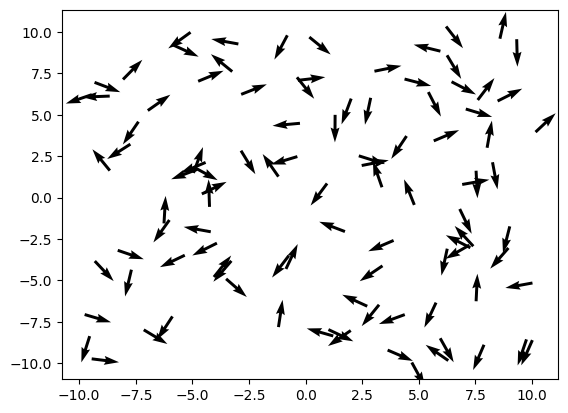

In [47]:
display_savestate(savestates[3])

We can visualize the whole simulation with an HTML animation.

In [48]:
from matplotlib.animation import FuncAnimation  # creates animation
from IPython.display import HTML                # displays animation

def make_animation(savestates):
    colors = np.random.rand(len(all_cells),)  # Color each cell for tracking
    fig, ax = plt.subplots()                  # Initialize figure axes

    def animate(frame):
        ax.clear()

        soa = map(lambda c: c.getvars(), savestates[frame])
        X, Y, Z, U = zip(*soa)
        ax.quiver(X, Y, Z, U, colors, cmap='rainbow') # gist_ncar is more obvious but this is prettier

        plt.xlim(-20, 20) # Add any matplotlib add-ons here
        plt.ylim(-20, 20)

    return FuncAnimation(fig, animate, frames=np.arange(0,100), interval=200)

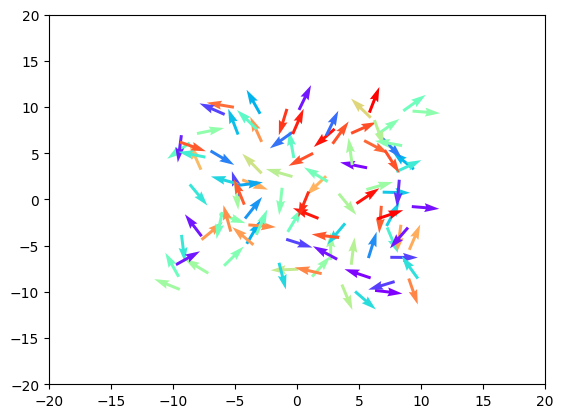

In [49]:
animation = make_animation(savestates)
HTML(animation.to_jshtml())

# Part 2: Quantifying the Model

Visualizations are all well and good, but we would like to draw quantitative conclusions from our model (in order to test our hypotheses, as well as statistically test our data).

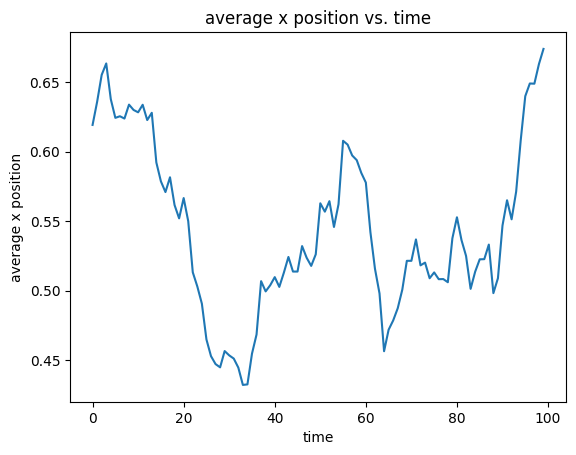

In [52]:
fig, axs = plt.subplots(1, 1) # <- It's worth getting acquainted with subplots!

x = np.arange(0,100)
y = []
for n in x:
  y.append(np.mean([c.x for c in savestates[n]]))

axs.plot(x,y)
plt.xlabel('time')
plt.ylabel('average x position')
plt.title('average x position vs. time')

plt.show()

**Bonus question:** How do we validate our model?

(Hint: Recall our previous lectures. What tools can we use to compare real biological data to a completely *in silico* model?)

## Summary

In this notebook we covered:

| Part | Topic | Key tool |
|------|-------|----------|
| 0 | Classes | classes, `__init__`, inheritance |
| 1 | Designing a Simplified Cell Model | `plt.quiver`, `matplotlib.animation` |
| 2 | Quantifying the Model | `plt.imshow` |

The central theme: **modeling is an iterative process**, and knowing how to visualize and interpret a model is key to doing good science *in silico*.